In [42]:
import pandas as pd
import seaborn as sns
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

In [43]:
img_labels = pd.read_csv("../data/ISIC_2019_Training_GroundTruth.csv")
img_labels.drop("UNK", axis=1, inplace=True) # remove unknown category
img_labels

,image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC
0,ISIC_0000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0000001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0000002,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0000003,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0000004,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
25326,ISIC_0073247,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
25327,ISIC_0073248,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
25328,ISIC_0073249,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25329,ISIC_0073251,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


Text(0, 0.5, 'Class Distribution')

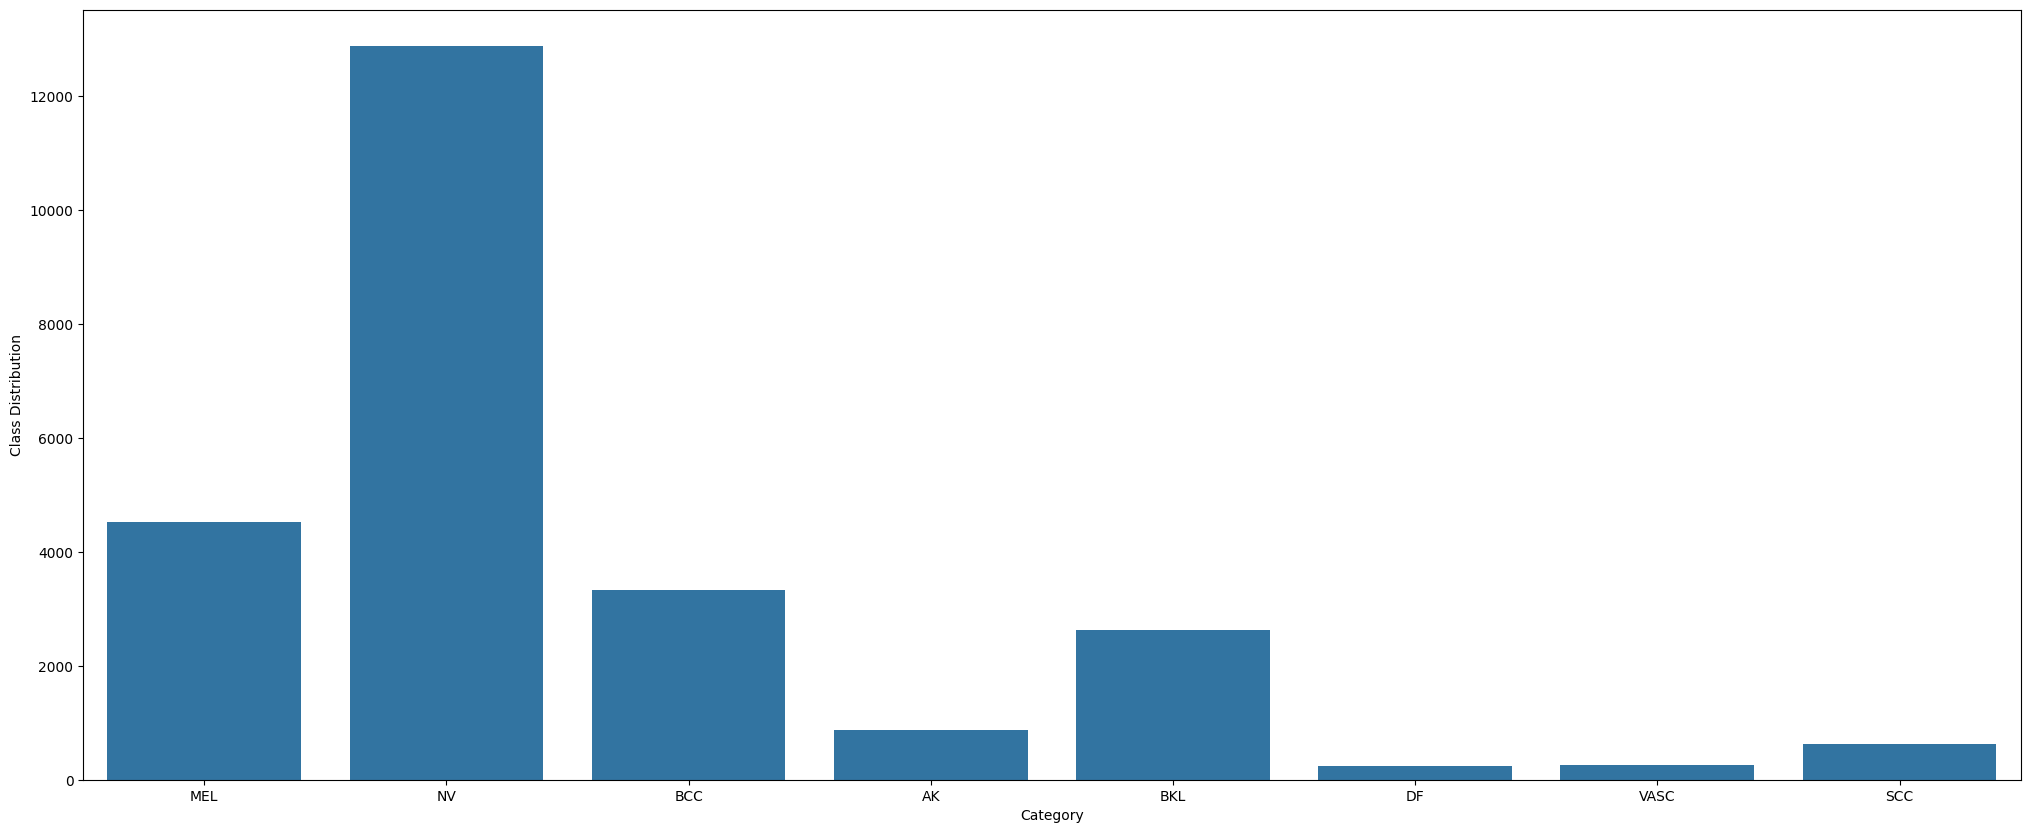

In [44]:
df = pd.melt(img_labels, id_vars=['image'], value_vars=img_labels.columns.to_list(), var_name='Category')
df = df[df['value'] == 1.0]

fig,axes = plt.subplots(1,1,figsize=(25, 10))

sns.countplot(df, x='Category')
axes.set_ylabel("Class Distribution")

In [45]:
for index, row in img_labels.iterrows():
    img_str = row['image']
    path = f'../data/ISIC_2019_Training_Input/{img_str}.jpg'
    downsampled = img_str.endswith("downsampled")
    
    img = Image.open(path)
    img_labels.loc[index, 'Height'] = img.height
    img_labels.loc[index, 'Width'] = img.width
    img_labels.loc[index, 'Aspect Ratio'] = img.width / img.height
    img_labels.loc[index, 'Size (KB)'] = os.stat(path).st_size // 1000
    img_labels.loc[index, "downsampled"] = downsampled
    
    img = img.convert("L")
    img_array = np.array(img)
    average_intensity = np.mean(img_array)
    
    img_labels.loc[index, 'Average Intensity'] = average_intensity
img_labels

,image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,Height,Width,Aspect Ratio,Size (KB),downsampled,Average Intensity
0,ISIC_0000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,767.0,1022.0,1.332464,49.0,False,146.011072
1,ISIC_0000001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,767.0,1022.0,1.332464,38.0,False,163.783566
2,ISIC_0000002,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,767.0,1022.0,1.332464,57.0,False,150.604959
3,ISIC_0000003,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,767.0,1022.0,1.332464,45.0,False,179.790553
4,ISIC_0000004,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,767.0,1022.0,1.332464,49.0,False,76.290813
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25326,ISIC_0073247,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1024.0,1024.0,1.000000,348.0,False,90.834301
25327,ISIC_0073248,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1024.0,1024.0,1.000000,464.0,False,135.804679
25328,ISIC_0073249,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1024.0,1024.0,1.000000,502.0,False,140.382604
25329,ISIC_0073251,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1024.0,1024.0,1.000000,415.0,False,114.900074


Text(0, 0.5, 'Intensity Distribution')

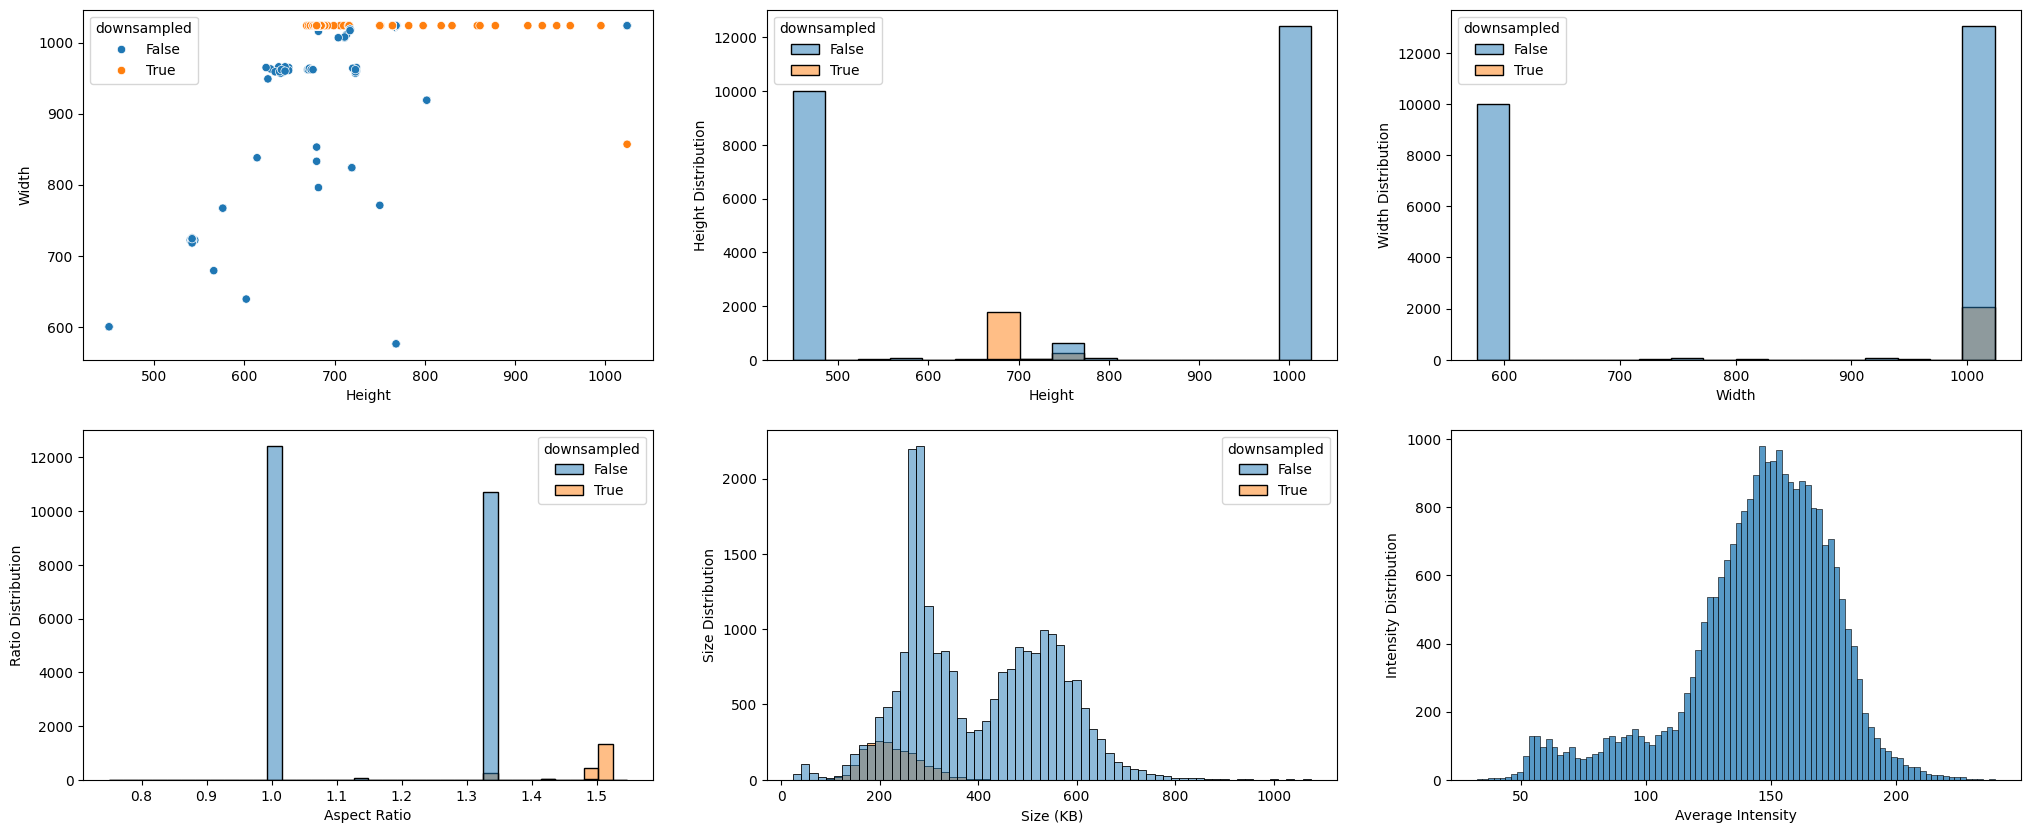

In [46]:
fig,axes = plt.subplots(2,3,figsize=(25, 10))

sns.scatterplot(data=img_labels, x="Height", y="Width", hue='downsampled', ax=axes[0][0])
sns.histplot(data=img_labels,x="Height", hue='downsampled', ax=axes[0][1])
sns.histplot(data=img_labels,x="Width", hue='downsampled', ax=axes[0][2])
sns.histplot(data=img_labels,x="Aspect Ratio", hue='downsampled', ax=axes[1][0])
sns.histplot(data=img_labels,x="Size (KB)", hue='downsampled', ax=axes[1][1])
sns.histplot(data=img_labels,x="Average Intensity", ax=axes[1][2])

axes[0][1].set_ylabel("Height Distribution")
axes[0][2].set_ylabel("Width Distribution")

axes[1][0].set_ylabel("Ratio Distribution")
axes[1][1].set_ylabel("Size Distribution")
axes[1][2].set_ylabel("Intensity Distribution")